# vLLM Benchmark Results Analysis
Visualize output from `run_benchmark.py`: Cold / Warm / Long Context phases.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import glob

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "DejaVu Sans", "SimHei"],
    "axes.unicode_minus": False,
    "figure.dpi": 120,
})

# Load the latest benchmark result CSV
result_files = sorted(glob.glob("results/benchmark_*.csv"))
if not result_files:
    raise FileNotFoundError("No benchmark result CSV found in results/. Run run_benchmark.py first.")

csv_path = result_files[-1]
print(f"Loading: {csv_path}")
df = pd.read_csv(csv_path)
df.head(10)


Loading: results/benchmark_20260218_124343.csv


,phase,label,input_tokens,output_tokens,ttft_ms,latency_ms,decode_tps,gpu_mem_peak_mb,success,error,timestamp
0,cold,first_request,81,256,285.151756,9196.622231,28.614806,20849.0,True,NaN,2026-02-18T12:41:23.293089+00:00
1,warm,run_1,81,256,49.278864,8966.714284,28.595665,20849.0,True,NaN,2026-02-18T12:41:32.523462+00:00
2,warm,run_2,81,256,47.911893,8966.626223,28.591565,20849.0,True,NaN,2026-02-18T12:41:41.524711+00:00
3,warm,run_3,81,256,47.758630,8977.528317,28.556168,20849.0,True,NaN,2026-02-18T12:41:50.548950+00:00
4,warm,run_4,81,256,49.764162,8969.671082,28.587742,20849.0,True,NaN,2026-02-18T12:41:59.556171+00:00
5,warm,run_5,81,256,47.796931,8962.252233,28.605225,20849.0,True,NaN,2026-02-18T12:42:08.542483+00:00
6,long_context,input_1024,1024,128,285.388240,4740.969382,28.503577,20849.0,True,NaN,2026-02-18T12:42:18.189528+00:00
7,long_context,input_2048,2048,128,523.881519,5017.963752,28.259385,20849.0,True,NaN,2026-02-18T12:42:25.737829+00:00
8,long_context,input_4096,4096,128,1078.179900,5599.090138,28.091688,20849.0,True,NaN,2026-02-18T12:42:42.218567+00:00
9,long_context,input_8192,8192,128,2341.412683,6949.598498,27.559653,20849.0,True,NaN,2026-02-18T12:43:36.736026+00:00


In [3]:
# Phase A: Cold Start
cold = df[df["phase"] == "cold"]
if not cold.empty:
    r = cold.iloc[0]
    print("=== Phase A: Cold Start ===")
    print(f"  TTFT         : {r['ttft_ms']:.1f} ms")
    print(f"  Total latency: {r['latency_ms']:.1f} ms")
    print(f"  Decode TPS   : {r['decode_tps']:.1f} tokens/s")
    print(f"  GPU mem peak : {r['gpu_mem_peak_mb']:.0f} MB")

=== Phase A: Cold Start ===
  TTFT         : 285.2 ms
  Total latency: 9196.6 ms
  Decode TPS   : 28.6 tokens/s
  GPU mem peak : 20849 MB


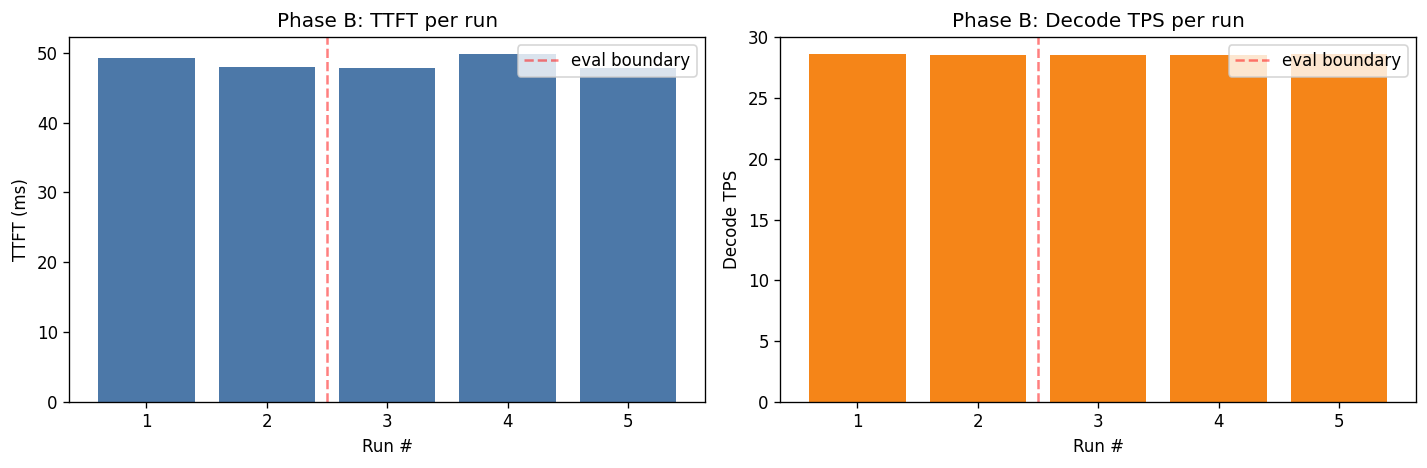

=== Phase B: Eval Runs (3-5) ===
  TTFT  p50=47.8ms  p95=49.6ms
  TPS   p50=28.6  p95=28.6


In [4]:
# Phase B: Warm Start — TTFT & TPS across runs
warm = df[df["phase"] == "warm"].copy()
if not warm.empty:
    warm["run"] = range(1, len(warm) + 1)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    ax1.bar(warm["run"], warm["ttft_ms"], color="#4C78A8")
    ax1.set_xlabel("Run #")
    ax1.set_ylabel("TTFT (ms)")
    ax1.set_title("Phase B: TTFT per run")
    ax1.axvline(x=2.5, color="red", linestyle="--", alpha=0.5, label="eval boundary")
    ax1.legend()

    ax2.bar(warm["run"], warm["decode_tps"], color="#F58518")
    ax2.set_xlabel("Run #")
    ax2.set_ylabel("Decode TPS")
    ax2.set_title("Phase B: Decode TPS per run")
    ax2.axvline(x=2.5, color="red", linestyle="--", alpha=0.5, label="eval boundary")
    ax2.legend()

    plt.tight_layout()
    plt.savefig("results/phase_b_warm.png", bbox_inches="tight")
    plt.show()

    # P50/P95 for eval runs (3-5)
    eval_runs = warm[warm["run"] >= 3]
    print("=== Phase B: Eval Runs (3-5) ===")
    print(f"  TTFT  p50={eval_runs['ttft_ms'].quantile(0.5):.1f}ms  p95={eval_runs['ttft_ms'].quantile(0.95):.1f}ms")
    print(f"  TPS   p50={eval_runs['decode_tps'].quantile(0.5):.1f}  p95={eval_runs['decode_tps'].quantile(0.95):.1f}")

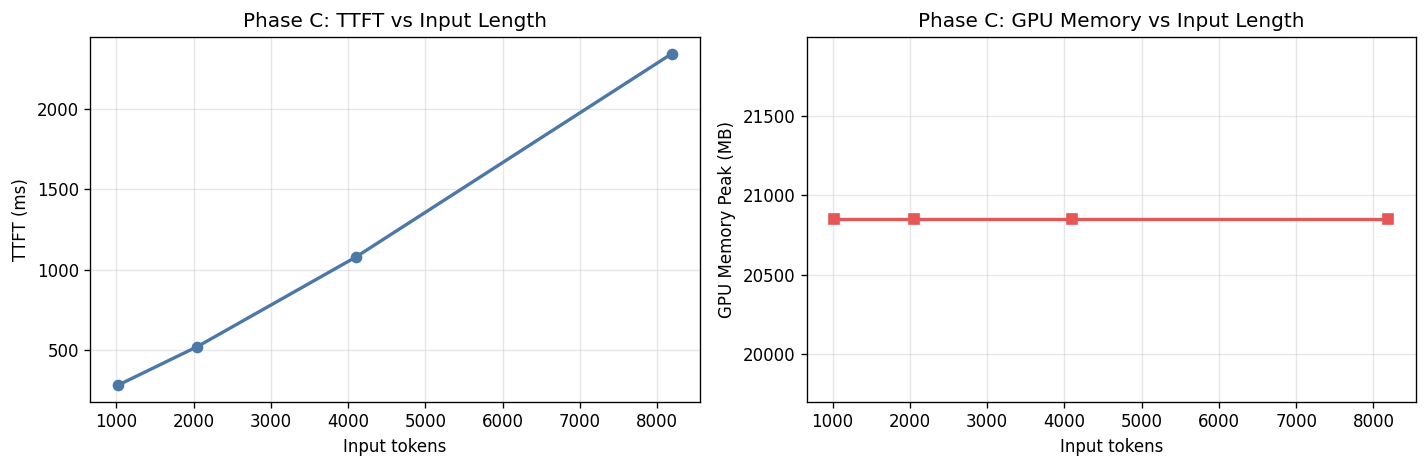

=== Phase C: Long Context Details ===
     label  input_tokens     ttft_ms  decode_tps  gpu_mem_peak_mb
input_1024          1024  285.388240   28.503577          20849.0
input_2048          2048  523.881519   28.259385          20849.0
input_4096          4096 1078.179900   28.091688          20849.0
input_8192          8192 2341.412683   27.559653          20849.0


In [5]:
# Phase C: Long Context — TTFT & GPU memory vs input length
lc = df[df["phase"] == "long_context"].copy()
if not lc.empty:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    ax1.plot(lc["input_tokens"], lc["ttft_ms"], marker="o", color="#4C78A8", linewidth=2)
    ax1.set_xlabel("Input tokens")
    ax1.set_ylabel("TTFT (ms)")
    ax1.set_title("Phase C: TTFT vs Input Length")
    ax1.grid(True, alpha=0.3)

    ax2.plot(lc["input_tokens"], lc["gpu_mem_peak_mb"], marker="s", color="#E45756", linewidth=2)
    ax2.set_xlabel("Input tokens")
    ax2.set_ylabel("GPU Memory Peak (MB)")
    ax2.set_title("Phase C: GPU Memory vs Input Length")
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig("results/phase_c_long_context.png", bbox_inches="tight")
    plt.show()

    print("=== Phase C: Long Context Details ===")
    print(lc[["label", "input_tokens", "ttft_ms", "decode_tps", "gpu_mem_peak_mb"]].to_string(index=False))

In [6]:
# Full summary table
print("=== Full Benchmark Results ===")
print(df[["phase", "label", "input_tokens", "output_tokens", "ttft_ms", "decode_tps", "gpu_mem_peak_mb", "success"]].to_string(index=False))

=== Full Benchmark Results ===
       phase         label  input_tokens  output_tokens     ttft_ms  decode_tps  gpu_mem_peak_mb  success
        cold first_request            81            256  285.151756   28.614806          20849.0     True
        warm         run_1            81            256   49.278864   28.595665          20849.0     True
        warm         run_2            81            256   47.911893   28.591565          20849.0     True
        warm         run_3            81            256   47.758630   28.556168          20849.0     True
        warm         run_4            81            256   49.764162   28.587742          20849.0     True
        warm         run_5            81            256   47.796931   28.605225          20849.0     True
long_context    input_1024          1024            128  285.388240   28.503577          20849.0     True
long_context    input_2048          2048            128  523.881519   28.259385          20849.0     True
long_context   